<!--Title and subtitle-->
# Your Model Is Cheating — And You Probably Don't Know It
How dataset splitting can silently inflates Bio-AI benchmarks, and what to do about it

---

<!--Hook and intro-->
You just trained a model. Accuracy: 91%. You lean back, satisfied. The loss curve is smooth, the validation metrics are clean, and the model just works. You write it up, share it with your team, maybe even start drafting a paper.

There's no warning sign. No red flag in your loss curves. The model looks honest, performs well in evaluation, and you have no reason to worry. But here's the uncomfortable truth: your evaluation is lying to you.

This isn't about overfitting in the traditional sense. The problem is more subtle, more insidious, and far more widespread in biological AI than most practitioners realize. It hides in a single line of code that almost everyone writes the same way:
```python
train, test = train_test_split(dataset, test_size=0.2)
```

In this post, we'll take a simple antimicrobial peptide efficiency predictor, and break it three times. Each time learning something new. By the end, you'll never look at a bio dataset split the same way again.

<!-- Project Overview-->
## Project Overview
Antimicrobial resistance is one of the most pressing public health challenges of our time. Bacteria are evolving faster than we can develop new antibiotics, and the pipeline of conventional drugs is running dry. We need new approaches — and one promising avenue is hiding in biology itself.

Over hundreds of millions of years, organisms from frogs to humans have been locked in an evolutionary arms race with bacteria. Their secret weapon? Antimicrobial peptides (AMPs) — short chains of amino acids, essentially miniature proteins, that can punch holes in bacterial membranes, disrupt their metabolism, or interfere with their DNA replication. Nature has been running this drug discovery program far longer than we have, and it has produced thousands of candidate molecules.

The problem is finding the good ones. Experimental screening is slow and expensive. This is exactly where machine learning comes in: if we can train a model to predict whether a peptide will be active against a target bacterium, we can screen millions of candidates computationally before ever touching a pipette.

That's our goal here. We'll build a model that takes a peptide sequence as input and predicts its activity against *Escherichia coli.* Simple, useful, and as we'll soon discover, surprisingly easy to get wrong.

## Installation
All the code snippets in this post are condensed for clarity — but if you want to run the full experiment yourself, the complete notebook is available [here](https://github.com/anthol42/blogs/blob/main/peptide_split/peptide_dataset_split.ipynb). To get started, install the required packages:

In [47]:
!uv add pandas numpy qmap-benchmark refnd torch esm tqdm

Resolved 170 packages in 4ms
Audited 148 packages in 38ms


You'll also need MMseqs2 installed as a system tool. On Mac:


In [ ]:
!brew install mmseqs2

In [45]:
# Small utils function to index python list like numpy arrays with a list of ints
def index(ls: list, idx: list[int]) -> list:
    return [s for i, s in enumerate(ls) if i in idx]

<!--Dataset preparation (Load DBAASP, convert MIC to binary)-->
## Dataset Preparation
To train a model, we need data — and fortunately, the field has done a lot of the heavy lifting for us. We'll use the [DBAASP database](https://dbaasp.org/home), one of the most comprehensive collections of antimicrobial peptides available, accessed through the [QMAP-benchmark](https://github.com/anthol42/QMAP) package which provides a curated, ready-to-use version of it.

Our target is MIC (Minimum Inhibitory Concentration): the smallest amount of peptide needed to stop a bacterial colony from growing. Lower MIC means more potent. We want to predict this value directly — a regression problem.

There's one important preprocessing step. MIC values span several orders of magnitude and follow a multiplicative scale — the meaningful unit is a fold-change, not an absolute difference. We therefore convert to log₁₀ space, which turns fold-changes into linear differences and makes our regression target well-behaved.

In [1]:
from qmap import DBAASPDataset
import numpy as np

dbaasp = DBAASPDataset().tabular(["id", "sequence", "Escherichia coli"])

# Keep only samples with E. coli MIC measured
dbaasp = dbaasp.loc[dbaasp["Escherichia coli"].notna()]

ds = dbaasp.copy(deep=True)
# Log space
targets = np.log10(dbaasp["Escherichia coli"].values)

We can visualize the MIC distribution:

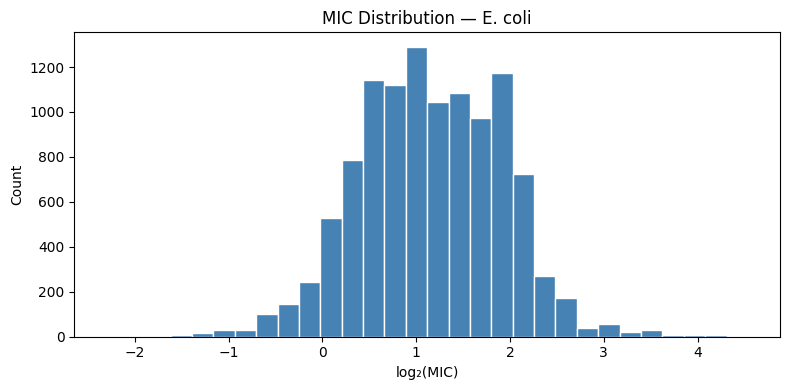

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(targets, bins=30, color="steelblue", edgecolor="white")
plt.xlabel("log₂(MIC)")
plt.ylabel("Count")
plt.title("MIC Distribution — E. coli")
plt.tight_layout()
plt.show()

<!--Modelling approach: ESM-C embeddings (SOTA) and Linear and MLP; Simple model as a starting point:)-->
## Starting Simple — Perhaps Too Simple
Now that we have the data, let's get to the fun part.

We'll keep things intentionally simple: a small prediction head trained on top of ESM-C embeddings. ESM-C is a state-of-the-art protein language model — it has been pretrained on hundreds of millions of protein sequences and produces rich, information-dense representations of any amino acid sequence. Think of it as the BERT of the protein world. We don't need to fine-tune it; we just use it as a frozen feature extractor and train a lightweight head on top.

We'll try two heads: a Linear regressor (our simplest possible baseline) and a small MLP (two layers with ReLU activations). The goal here isn't to win a competition — it's to get something working in an afternoon, and to show that even simple models are vulnerable to the problem we're about to uncover.

> **Note:**
> 
> The embedding and model code below is mostly boilerplate — feel free to skim it and come back later when you need it.
> 
> We'll precompute the embeddings once here and reuse them across all experiments.

In [3]:
import torch
import torch.nn as nn
from tqdm import tqdm
from esm.models.esmc import ESMC
from esm.sdk.api import ESMProtein, LogitsConfig

# ── Embeddings
def get_embeddings(
    peptides: list[str],
    batch_size: int = 512,
) -> torch.Tensor:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    client = ESMC.from_pretrained("esmc_300m").to(device)
    client.eval()

    pad_id = client.tokenizer.pad_token_id
    eos_id = client.tokenizer.eos_token_id

    all_embeddings = []

    with torch.no_grad():
        for i in tqdm(range(0, len(peptides), batch_size), desc="Embedding"):
            batch = peptides[i : i + batch_size]

            tokens_list = [
                client.encode(ESMProtein(sequence=seq)).sequence
                for seq in batch
            ]
            tokens = torch.nn.utils.rnn.pad_sequence(
                tokens_list, batch_first=True, padding_value=pad_id
            ).to(device)  # (B, L_max)

            mask = (tokens != pad_id) & (tokens != eos_id)
            mask[:, 0] = False  # exclude BOS

            emb = client(tokens).embeddings  # (B, L_max, D)

            for j in range(len(batch)):
                m = mask[j]
                all_embeddings.append(emb[j, m, :].mean(dim=0).cpu())

    return torch.stack(all_embeddings)  # (N, D)

# ── Model heads 

ESM_DIM = 960  # hidden dimension of ESM-C 300M

class LinearHead(nn.Module):
    """Single linear layer: a simple logistic regression baseline."""
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(ESM_DIM, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc(x).squeeze(-1)  # (B,)


class MLPHead(nn.Module):
    """Two-layer MLP with ReLU activation and 2x hidden dimension."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(ESM_DIM, ESM_DIM * 2),
            nn.ReLU(),
            nn.Linear(ESM_DIM * 2, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)  # (B,)

# We'll precompute the embeddings once here and reuse them across all experiments.
y = torch.tensor(targets).float()
X = get_embeddings(ds["sequence"])

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Embedding: 100%|███████████████████████████████████████████████████| 22/22 [10:19<00:00, 28.15s/it]


Next, we implement our splitting utility — intentionally mirroring sklearn's `train_test_split` interface so it stays familiar. We'll call it twice: once to carve out the test set, then again to split the remainder into train and validation.

In [8]:
from sklearn.model_selection import train_test_split

def random_split(
    X: torch.Tensor,
    y: torch.Tensor,
    sequences: list[str],
    test_size: float = 0.2,
    seed: int = 42,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Split indices into train and test. Mirrors the sklearn interface."""
    X_train, X_test, y_train, y_test, seq_train_rnd, seq_test_rnd = train_test_split(
        X, y, sequences, test_size=test_size, random_state=seed
    )
    return X_train, X_test, y_train, y_test, seq_train_rnd, seq_test_rnd

Now the training loop. The Linear head trains for a fixed number of epochs; the MLP uses early stopping on validation loss.

In [9]:
from scipy.stats import pearsonr

def train(
    model: nn.Module,
    X_train: torch.Tensor,
    y_train: torch.Tensor,
    X_val: torch.Tensor,
    y_val: torch.Tensor,
    epochs: int = 100,
    lr: float = 1e-3,
    patience: int = 10,
    use_early_stopping: bool = False,
    batch_size: int = 64,
) -> nn.Module:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    X_train, y_train, X_val, y_val = (
        X_train.to(device),
        y_train.to(device),
        X_val.to(device),
        y_val.to(device),
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_val_loss     = float("inf")
    best_state        = None
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(len(X_train), device=device)
        for i in range(0, len(X_train), batch_size):
            idx = perm[i : i + batch_size]
            optimizer.zero_grad()
            loss = criterion(model(X_train[idx]), y_train[idx])
            loss.backward()
            optimizer.step()

        if use_early_stopping:
            model.eval()
            with torch.no_grad():
                val_loss = criterion(model(X_val), y_val).item()
            if val_loss < best_val_loss:
                best_val_loss     = val_loss
                best_state        = {k: v.clone() for k, v in model.state_dict().items()}
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    break

    if use_early_stopping and best_state is not None:
        model.load_state_dict(best_state)

    return model.cpu()


def evaluate(
    model: nn.Module,
    X_test: torch.Tensor,
    y_test: torch.Tensor,
) -> float:
    """Returns Pearson correlation between predictions and targets."""
    model.eval()
    with torch.no_grad():
        preds = model(X_test).numpy()
    targets = y_test.numpy()
    r, _ = pearsonr(preds, targets)
    return r

Let's put everything together. We train both models on a random split and record test accuracy — this will be our first two rows in the results table.

In [10]:
sequences = ds["sequence"].to_list()
# Split
X_train, X_test, y_train, y_test, seq_train_rnd, seq_test_rnd = random_split(X, y, sequences)
X_train, X_val, y_train, y_val, seq_train_rnd, seq_val_rnd = random_split(X_train, y_train, seq_train_rnd)

# Linear head
linear_model = LinearHead()
linear_model = train(linear_model, X_train, y_train, X_val, y_val,
                     epochs=100, lr=1e-3, use_early_stopping=False)
linear_pcc_random = evaluate(linear_model, X_test, y_test)

# MLP head
mlp_model = MLPHead()
mlp_model = train(mlp_model, X_train, y_train, X_val, y_val,
                  epochs=300, lr=1e-3, use_early_stopping=True, patience=15)
mlp_pcc_random = evaluate(mlp_model, X_test, y_test)

# Display results
print(f"{'Model':<12} {'Random Split':>14}")
print(f"{'-'*28}")
print(f"{'Linear':<12} {linear_pcc_random:>13.1%}")
print(f"{'MLP':<12} {mlp_pcc_random:>13.1%}")

Model          Random Split
----------------------------
Linear               61.2%
MLP                  69.0%


Those numbers just made your heart skip a beat, didn't they? A linear model. A tiny MLP. Trained in seconds, on your laptop, on a real biological dataset. No fine-tuning. No fancy architecture. No years of domain expertise. Just frozen embeddings and a few matrix multiplications standing between you and what looks like a genuinely useful drug discovery tool.

We may have just revolutionized drug discovery!

*...or did we?*

Before we celebrate, let's do something we should have done from the start — look at the data. But instead of vizualizing only the training set, let's compare the train and test.  Not just the training set, but how the training and test sets relate to each other. Using [refnd](https://github.com/anthol42/refnd)'s exact nearest neighbor search, we can find, for each test sequence, its closest match in the training set:

In [56]:
from refnd import exact_nearest_neighbors, KernelVariant

test_neighbors_in_train = exact_nearest_neighbors(KernelVariant.ProteinGlobal, seq_test_rnd[:10], seq_train_rnd, k=1)
for test_seq, neighbors in zip(seq_test_rnd[:10], test_neighbors_in_train):
    nn_idx, dist = neighbors[0]
    nn_train_seq = seq_train_rnd[nn_idx]
    # Note that we do 1 - dist as refnd uses a distance measure, not similarity. So we need to do 1 - dist to get the identity.
    print(f"Test: {test_seq} <--> Train: {nn_train_seq} [{100*(1 - dist):.0f}%]")

Test: KEERGAPKGCWTKSYPPKPCSGKR <--> Train: AALKGCWTKSIPPKPCFGKR [67%]
Test: KRFWPLVPVAINTVAAGIN <--> Train: KRFWPLVPVAINTVA [79%]
Test: FLKLIGKVLSGIL <--> Train: FLPLIGKVLSGIL [92%]
Test: GIGKFLHSAKKFGKAFVGEIMNS <--> Train: GIGKFLHSAKKFGKAFVGEIMNS [100%]
Test: WRKVWRpGVKRWVK <--> Train: RWVKVPGRWVKV [60%]
Test: WLNALKKVWQGIHEAIKLIWNWVQ <--> Train: WLNALKKVFQGIHEAIKLIWNWVQ [96%]
Test: KWRRWVRWI <--> Train: KWRRWVRWI [100%]
Test: KIAGKIASIAGKIAKIAGKIAKIA <--> Train: KIAGKIAAIAGKIAKIAGKIAKIA [96%]
Test: KALXKTMLKKLGTMAL <--> Train: ALXKTMLKKLGTMAL [94%]
Test: SVIGCWTKSIPPRPCFVK <--> Train: IGCWTKSIPPRPCFVK [89%]


The output is striking. Most test sequences have a highly similar counterpart in the training set — and some even share 100% identity, meaning there are outright duplicates across our split. Could this be inflating our results?

Let's think about what this actually means biologically. In nature, new peptides emerge through random mutations that accumulate slowly over time. A single mutation rarely changes a peptide's function — it takes many generations of divergence for activity to shift meaningfully. This is why we can think of peptides as families: groups of similar sequences that share similar activity profiles. 

Now consider what our model might be doing. Rather than learning a general mapping from sequence to activity, it may have simply learned the average MIC of each peptide family present in the training data. Applied to a test set drawn from those same families, it looks brilliant. But expose it to a genuinely novel family — one it has never seen a variant of — and it would likely fall apart.

The uncomfortable truth is that with a random split, we can't even tell the difference. Our test set is just a random sample of the same families as our training set. We are not evaluating generalization. We are evaluating memorization.

## A Smarter Split
Our dataset of ~15k samples barely scratches the surface of the peptide design space — the probability that every biologically relevant family is represented in our training data is essentially zero. A model that can only predict activity for variants of sequences it has already seen is not a useful screening tool, it's a lookup table. What we actually need is a model that can extrapolate to entirely new families, the ones that haven't been discovered yet.

To test whether our model can actually do this, we need a test set composed of families it has never seen during training.

Fortunately, we can infer peptide families directly from the data — by clustering sequences based on similarity. Sequences that cluster together share enough identity to be considered members of the same family. If we then split the dataset at the cluster level — some clusters go entirely to train, others entirely to test — we guarantee that the model is evaluated on genuinely novel families.

Formally, we can represent this as a proximity graph: a network where each sequence is a node, and two nodes are connected by an edge if their identity exceeds our similarity threshold. Clusters of related sequences naturally become connected subgraphs in this graph.

To cluster our peptides, we'll use [MMseqs2](https://github.com/soedinglab/mmseqs2), a fast and widely adopted sequence clustering tool. Everything else stays exactly the same — same models, same optimizer, same hyperparameters. The only thing that changes is the split.

The core of the approach is just three steps — the full implementation is in the notebook, but here's what it does:
1. Cluster sequences with mmseqs easy-cluster using exact local alignment at 50% identity
2. Parse the resulting cluster assignments
3. Randomly assign whole clusters to train or test — never splitting a cluster across both

In [34]:
import os
import subprocess

def mmseqs_cluster_split(
    X: torch.Tensor,
    y: torch.Tensor,
    sequences: list[str],
    test_size: float = 0.2,
    min_seq_id: float = 0.5,
    workdir: str = "mmseqs_cluster_split",
    seed: int = 42,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, list[str], list[str]]:
    """
    Split X, y into train and test by clustering sequences with MMseqs2
    easy-cluster, then assigning whole clusters to train or test.
    No sequences are removed — entire clusters are kept intact.
    Mirrors the sklearn interface.

    Returns
    -------
    X_train, X_test, y_train, y_test, sequences_train, sequences_test
    """
    os.makedirs(workdir, exist_ok=True)
    indices = np.arange(len(X))

    # ── Step 1: Write full dataset FASTA ─────────────────────────────────────
    fasta_path = f"{workdir}/all.fasta"
    with open(fasta_path, "w") as f:
        for i in indices:
            f.write(f">{i}\n{sequences[i]}\n")

    # ── Step 2: Cluster with MMseqs2 easy-cluster ─────────────────────────────
    cluster_prefix = f"{workdir}/clusters"
    cmd = (
        f"mmseqs easy-cluster {fasta_path} {cluster_prefix} {workdir}/tmp "
        f"--min-seq-id {min_seq_id} "
        f"--alignment-mode 3 "
        f"--gap-open 11 "
        f"--gap-extend 1 "
        f"--cov-mode 1 "
        f"--cluster-mode 1 "   # We want to ensure that a cluster encompass all peptides in the family
        f"--comp-bias-corr 0 " # No bias correction, peptides
        f"-s 7.5" # Highly sensitive
    )
    subprocess.run(cmd, shell=True, check=True, 
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
                  )

    # ── Step 3: Parse cluster TSV ─────────────────────────────────────────────
    # Output format: representative_id \t member_id
    clusters: dict[str, list[int]] = {}
    with open(f"{cluster_prefix}_cluster.tsv") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 2:
                rep, member = parts[0], parts[1]
                clusters.setdefault(rep, []).append(int(member))

    cluster_ids   = list(clusters.keys())
    cluster_sizes = [len(clusters[c]) for c in cluster_ids]
    print(f"Found {len(cluster_ids)} clusters for {len(sequences)} sequences")

    # ── Step 4: Greedily assign clusters to test until test_size is reached ───
    rng = np.random.default_rng(seed)
    shuffled = rng.permutation(len(cluster_ids))

    test_indices  = []
    train_indices = []
    n_test_target = int(len(sequences) * test_size)

    for i in shuffled:
        if len(test_indices) < n_test_target:
            test_indices.extend(clusters[cluster_ids[i]])
        else:
            train_indices.extend(clusters[cluster_ids[i]])

    train_idx = np.array(train_indices)
    test_idx  = np.array(test_indices)

    print(f"Split: {len(train_idx)} train / {len(test_idx)} test sequences")

    sequences_train = [sequences[i] for i in train_idx]
    sequences_test  = [sequences[i] for i in test_idx]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx], sequences_train, sequences_test

In [39]:
sequences = ds["sequence"].tolist()
X_train, X_test, y_train, y_test, seq_train_mm, seq_test_mm = mmseqs_cluster_split(X, y, sequences)
X_train, X_val,  y_train, y_val,  seq_train_mm, seq_val_mm  = mmseqs_cluster_split(X_train, y_train, seq_train_mm, workdir="mmseqs_split/val")

dropped_sequence = len(X) - len(X_train) - len(X_test) - len(X_val)
print(f"Dropped {dropped_sequence} sequences")

# Linear head
linear_model = LinearHead()
linear_model = train(linear_model, X_train, y_train, X_val, y_val,
                     epochs=100, lr=1e-3, use_early_stopping=False)
linear_acc_mm = evaluate(linear_model, X_test, y_test)

# MLP head
mlp_model = MLPHead()
mlp_model = train(mlp_model, X_train, y_train, X_val, y_val,
                  epochs=300, lr=1e-3, use_early_stopping=True, patience=15)
mlp_acc_mm = evaluate(mlp_model, X_test, y_test)

# Display results
print(f"{'Model':<12} {'Random Split':>14}")
print(f"{'-'*28}")
print(f"{'Linear':<12} {linear_acc_mm:>13.1%}")
print(f"{'MLP':<12} {mlp_acc_mm:>13.1%}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Found 4260 clusters for 11059 sequences
Split: 8848 train / 2211 test sequences


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Found 3414 clusters for 8848 sequences
Split: 7079 train / 1769 test sequences
Dropped 0 sequences
Model          Random Split
----------------------------
Linear               61.1%
MLP                  60.8%


The results show a sharp drop in performance for the MLP, suggesting it was effectively overfitting to known peptide families rather than learning to generalize. Interestingly, the Linear model and MLP now perform similarly, suggesting that adding non-linearities doesn't help once you remove the family leakage.

The performances are still good — and now we feel confident we earned them. Our evaluation is rigorous, and representative of true generalization to new peptide families.

*...or is it?*

Let's run the same sanity check as before and look at the actual similarities between our train and test sequences:

In [42]:
test_neighbors_in_train = exact_nearest_neighbors(KernelVariant.ProteinGlobal, seq_test_mm[:10], seq_train_mm, k=1)
for i, (test_seq, neighbors) in enumerate(zip(seq_test_mm[:10], test_neighbors_in_train)):
    nn_idx, dist = neighbors[0]
    nn_train_seq = seq_train_mm[nn_idx]
    print(f"[{i}] Test: {test_seq} <--> Train: {nn_train_seq} [{100*(1 - dist):.0f}%]")

[0] Test: DRDRPECSTMVKYEQKLPSLGKYALKRAIKIKFGRK <--> Train: IWSFLIKAATKLLPSLFGGGKKFS [31%]
[1] Test: QNCPTRRGLCVTSGLTACRNHCRSCHRGDVGCVRCSNAQCTGFLGTTCTCINPCPRC <--> Train: ATCDLLSGTGVGHSACAAHCLLRGNRGGYCNGKGVCVCRN [28%]
[2] Test: QSCPTRRGLCFTSGLAACRAHCRGCHLGSNGRDCVRCPNGAQCTGVIGQTCTCLNPCPVC <--> Train: SGRGKTGGKARAKAKTRSSRAGLQFPVGRVHRLLRKGNYAQRVGAGAPVY [26%]
[3] Test: GIKFFLKKLKKHI <--> Train: GLLKKLLKKLLKKI [57%]
[4] Test: OOWWOWIOW <--> Train: OOWWOWWOO [78%]
[5] Test: KWKKNWTKIIQGFLKGGIGTILNLKKK <--> Train: GVVDIIKGAGKKFAKGLAGKIANKK [41%]
[6] Test: rllrllrlll <--> Train: RLLRLLRLLL [100%]
[7] Test: EWAAARQVIIHATRKY <--> Train: AARIILRTRFR [44%]
[8] Test: RKMKRVWKRFKL <--> Train: RKLKRFWKRVKM [67%]
[9] Test: SKYR <--> Train: WWKRR [40%]


Something is clearly still wrong. We set a 50% identity threshold — yet pairs [3], [4], [6], and [8] all exceed it. Sample [4] differs by only two residues. Sample [6] is a 100% identity match, the only difference being that one sequence uses D-amino acids (lowercase) while the other uses L-amino acids. By our own 50% threshold definition, these sequences should belong to the same cluster, and end up in the same split.

Something is wrong, why is it happening?

My intuition for why this happens points to how MMseqs2 works under the hood. Proper sequence clustering requires building a similarity graph where every pair of sequences above the identity threshold is connected — clusters then become the connected components of that graph. But this is an O($n^2$) problem: comparing every pair is too slow at scale. MMseqs2 relies on k-mer inverted index approximations to find candidate pairs before doing full alignment. While much faster, this approximation breaks down for short peptides, so edges get missed. Clusters that should be merged stay separated, meaning highly similar sequences can end up in different clusters — and ultimately on opposite sides of the split, which is exactly what we're observing.

To make this less compute intensive, MMseqs2 relies on approximations to make the algorithm much faster. These approximations do not work well on peptides, making the algorithm miss a lot sample similarities, thus edges in the graph. This makes smaller clusters that should be connected together, but are not, yielding clusters that shares high-smilarity samples in different clusters.

We need a tool that is built for exactly this problem.

## The Right Tool for the Job

Our intuition was right — building a test set from unseen families is the correct approach. MMseqs2 just wasn't designed for this: it's a powerful database search tool, but building an exhaustive proximity graph for short sequences is not what it was made for. We need something purpose-built for exactly this problem. Enter [Refnd](https://github.com/anthol42/refnd) — a package designed specifically to build thresholded proximity graphs efficiently, without making any assumptions about the underlying data. In practice, it works equally well for proteins, peptides, genes, or molecules — anything you can define a similarity function for.

Under the hood, refnd uses a **Hierarchical Navigable Small World (HNSW) index** — a data structure that builds an approximate proximity graph with O(log n) insertion and search complexity, making it fast even at scale. Crucially, it makes no assumptions about the similarity function: it works even when the metric doesn't respect the triangle inequality, as is the case with raw sequence identity. The default hyperparameters achieve 95%+ recall on all edges of the proximity graph on our dataset — meaning almost no similar pairs get missed.

Beyond graph construction, refnd provides a community detection algorithm. Rather than connected components — where, in our dataset, a single component can absorb three quarters of all sequences — communities find denser, more granular groupings within the graph. This gives us finer-grained clusters and a more balanced split. 

![Component-based VS Community based clustering](https://raw.githubusercontent.com/anthol42/blogs/refs/heads/main/peptide_split/community_detection.svg?token=GHSAT0AAAAAADC4PUUZTSHGUVKJB3NKA3U42QUTW5A)

In [52]:
from refnd.core import HNSWState, find_communities, partition
from refnd.kernels import KernelVariant

def homology_split(
    X: torch.Tensor, y: torch.Tensor, sequences: list[str], test_size: float = 0.2, min_seq_id: float = 0.5,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    # 1. Build the HNSW index and extract the proximity graph
    hnsw = HNSWState(KernelVariant.ProteinGlobal, sequences, proximity_threshold=min_seq_id)
    hnsw.build()
    graph = hnsw.edges().graph()

    # 2. Find communities as clusters
    clusters = find_communities(graph)
    n_components = len(np.unique(clusters))

    # 3. Partition along cluster boundaries
    train_idx, test_idx = partition(clusters, graph, test_ratio=test_size, post_filtering=True, seed=42)

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx], index(sequences, train_idx), index(sequences, test_idx)

One detail worth highlighting: we use `post_filtering=True`. Because we split along communities rather than connected components, there may be sequences in the train set that share an edge with a test sequence — meaning they are above our similarity threshold. Post-filtering removes those sequences from train explicitly. We trade a small number of training samples for a genuinely clean boundary — a worthwhile tradeoff when some peptide families are large enough that using connected components would pull a disproportionate fraction of the dataset into a single cluster.

Same interface, one line. Let's use this split to see what the numbers look like now.

In [67]:
X_train, X_test, y_train, y_test, seq_train_ho, seq_test_ho = homology_split(X, y, sequences)
X_train, X_val, y_train, y_val, seq_train_ho, seq_val_ho = homology_split(X_train, y_train, seq_train_ho)

dropped_sequence = len(X) - len(X_train) - len(X_test) - len(X_val)
print(f"Dropped {dropped_sequence} sequences")

# Linear head
linear_model = LinearHead()
linear_model = train(linear_model, X_train, y_train, X_val, y_val,
                     epochs=100, lr=1e-3, use_early_stopping=False)
linear_acc_random = evaluate(linear_model, X_test, y_test)

# MLP head
mlp_model = MLPHead()
mlp_model = train(mlp_model, X_train, y_train, X_val, y_val,
                  epochs=300, lr=1e-3, use_early_stopping=True, patience=15)
mlp_acc_random = evaluate(mlp_model, X_test, y_test)

# Display results
print(f"{'Model':<12} {'Random Split':>14}")
print(f"{'-'*28}")
print(f"{'Linear':<12} {linear_acc_random:>13.1%}")
print(f"{'MLP':<12} {mlp_acc_random:>13.1%}")

Dropped 2323 sequences
Model          Random Split
----------------------------
Linear               52.6%
MLP                  51.6%


The results dropped significantly, again. But did we actually fix the problem this time? Let's run the same sanity check:

In [68]:
test_neighbors_in_train = exact_nearest_neighbors(KernelVariant.ProteinGlobal, seq_test_ho[:10], seq_train_ho, k=1)
for i, (test_seq, neighbors) in enumerate(zip(seq_test_ho[:10], test_neighbors_in_train)):
    nn_idx, dist = neighbors[0]
    nn_train_seq = seq_train_ho[nn_idx]
    print(f"[{i}] Test: {test_seq} <--> Train: {nn_train_seq} [{100*(1 - dist):.0f}%]")

[0] Test: GMASKAGAIAGKIAKVALKAL <--> Train: GwGsffkkaahaGkhaGkaalthyl [48%]
[1] Test: kGGGkWGGkGGk <--> Train: KGRGKQGGKVRAKA [50%]
[2] Test: KVvvKWVvKvVK <--> Train: AVAVVGQAATVVK [46%]
[3] Test: KLllKWLlKlLK <--> Train: GMAKLLAKVLPHVVKLIK [44%]
[4] Test: ALWKTLLKKVLKAAA <--> Train: WMTLLKKVLKAAAKAALNAVLVGANA [46%]
[5] Test: LWKTLLKKVLKAAA <--> Train: WMTLLKKVLKAAAKAALNAVLVGANA [46%]
[6] Test: WKTLLKKVLKAAA <--> Train: GIWKSLFTKLLKG [46%]
[7] Test: KTLLKKVLKAAA <--> Train: TLLKKVLKAAAKAALNAVLVGANA [46%]
[8] Test: TLLKKVLKAAA <--> Train: TLLKKVLKAAAKAALNAVLVGANA [46%]
[9] Test: KLALKLALKAWKAALKLA <--> Train: GGLRSLGLKILLAWKKYG [44%]


Not a single pair exceeds the 50% threshold. For the first time, our split is actually respecting the constraint we set. But ten samples is not enough to be sure — let's get a more complete picture by plotting, for every test sequence across all three splits, the identity to its nearest neighbor in the training set:

In [69]:
from refnd.core import exact_nearest_neighbors
from refnd.kernels import KernelVariant

def plot_max_identity_distribution(
    train_sequences: list[str],
    test_sequences: list[str],
    label: str,
    ax: plt.Axes,
    color: str = "steelblue",
) -> None:
    """
    For each test sequence, find its most similar sequence in the train set
    using exact nearest-neighbor search, then plot the identity distribution.
    """
    results = exact_nearest_neighbors(
        KernelVariant.ProteinGlobal,
        queries=test_sequences,
        references=train_sequences,
        k=1,
    )
    # Extract the top-1 identity score for each test sequence.
    # We do 1 - x because `exact_nearest_neighbors` returns a distance, so 1 - identity
    max_identities = [1 - hits[0][1] for hits in results if hits]

    ax.hist(max_identities, bins=35, color=color, edgecolor="white", alpha=0.85, range=(0, 1))
    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.set_xlabel("Max identity to nearest train neighbor")
    ax.set_ylabel("Count")
    ax.axvline(x=0.5, color="red", linestyle="--", linewidth=1.5, label="50% threshold")
    ax.legend()

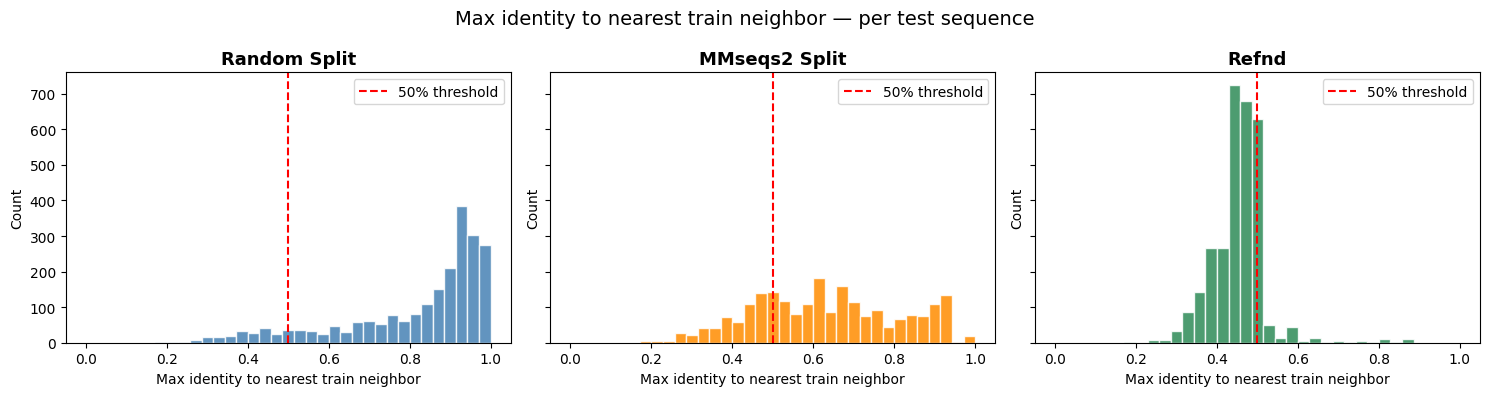

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

splits = [
    (seq_train_rnd, seq_test_rnd,        "Random Split",   "steelblue"),
    (seq_train_mm,     seq_test_mm,     "MMseqs2 Split",  "darkorange"),
    (seq_train_ho,    seq_test_ho,    "Refnd", "seagreen"),
]

for ax, (tr_seq, ts_seq, label, color) in zip(axes, splits):
    plot_max_identity_distribution(
        train_sequences=tr_seq,
        test_sequences= ts_seq,
        label=label,
        ax=ax,
        color=color,
    )

plt.suptitle("Max identity to nearest train neighbor — per test sequence", fontsize=14)
plt.tight_layout()
plt.show()

Now the full picture comes into focus. The random split shows a large proportion of test sequences with very high identity to their nearest train neighbor — many well above the 50% threshold, some at 100%. The MMseqs2 split is an improvement, but the constraint is still violated by a significant fraction of pairs. The Refnd split is in a different league entirely: the distribution is sharply concentrated below the threshold, with only a thin tail of violations.

That tail is expected and nothing to worry about. The HNSW graph is approximate by design — a small number of edges will be missed. For a perfect split, `refnd` also provides an exact O(n²) proximity graph that eliminates even those rare violations. But for any practical purpose, what we have here is clean.

The picture is now complete. Our simple linear model and MLP performed suspiciously well from the start. We were surprised, excited even. But the identity distributions tell the real story: the random split was flooding the test set with near-duplicate sequences, the MMseqs2 split left the job half-done, and only with refnd did we get what we actually wanted. The performance drop wasn't the model getting worse — it was our evaluation finally getting honest.

This happened because of hidden relationships between samples — relationships that standard splits silently ignore. In biological datasets, these relationships are everywhere: homologous proteins, related molecules, genes from related organisms. **Is your dataset at risk?**